In [5]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_NAME = "allenai/Molmo2-8B"
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    dtype=torch.float32,
    device_map="auto",
)
model.eval()

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


Molmo2ForConditionalGeneration(
  (model): Molmo2Model(
    (transformer): Molmo2TextModel(
      (wte): Molmo2Embedding()
      (emb_drop): Dropout(p=0.0, inplace=False)
      (blocks): ModuleList(
        (0-35): 36 x Molmo2DecoderLayer(
          (self_attn): Molmo2Attention(
            (att_proj): Linear(in_features=4096, out_features=6144, bias=False)
            (k_norm): Molmo2RMSNorm((128,), eps=1e-06)
            (q_norm): Molmo2RMSNorm((128,), eps=1e-06)
            (attn_out): Linear(in_features=4096, out_features=4096, bias=False)
          )
          (attn_norm): Molmo2RMSNorm((4096,), eps=1e-06)
          (dropout): Dropout(p=0.0, inplace=False)
          (mlp): LanguageModelMLP(
            (ff_proj): Linear(in_features=4096, out_features=24576, bias=False)
            (ff_out): Linear(in_features=12288, out_features=4096, bias=False)
            (act): SiLUActivation()
          )
          (ff_norm): Molmo2RMSNorm((4096,), eps=1e-06)
        )
      )
      (ln_f): M

In [6]:
from heca.helper import molmo

images, prompts, ground_truths, task_names, letters_per_task = molmo.get_data()

Prompt for drawer:
Given the following properties of a drawer:
- shape: rectangular box
- material: wood
- color: brown
- position: Located on the front of the workbench
- extra: The drawer has a grey handle to open and close.

Locate the drawer and decide what state it has.
You can choose from the following options for the state:
A: open
B: closed

Answer with exactly one of the letters [A, B] corresponding to the correct answer.

Prompt for light:
Given the following properties of a light:
- shape: rectangular cube
- material: Not specified, but likely plastic
- position: Located on the workbench surface in the top left area
- extra: The cube has a jagged bottom

Locate the light and decide what color it has.
You can choose from the following options for the color:
A: green 
B: white

Answer with exactly one of the letters [A, B] corresponding to the correct answer.

Prompt for slider:
Given the following properties of a slider:
- shape: rectangular door
- material: wood
- color: bro

In [7]:
chat_texts = []
for prompt in prompts:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    chat_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    chat_texts.append(chat_text)

In [8]:
predicted_letters = []
probs_predicted = []
# token ids for A/B/C
tokenizer = processor.tokenizer
tokens = {}
for letter in molmo.ALPHABET:
    token = tokenizer.encode(letter, add_special_tokens=False)[0]
    tokens[letter] = token

batch_size = 10
batch_indexes = list(range(0, len(images), batch_size))

for i in batch_indexes:
    img_batch = images[i : i + batch_size]
    chat_batch = chat_texts[i : i + batch_size]
    task_batch = task_names[i : i + batch_size]
    inputs = processor(
        images=img_batch,
        text=chat_batch,
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    inputs.pop("token_type_ids", None)

    with torch.inference_mode():
        outputs = model(**inputs)

    logits = outputs.logits  # [B, seq_len, vocab_size]

    # last valid token position for each sample
    input_lengths = inputs["attention_mask"].sum(dim=1) - 1

    for i in range(logits.shape[0]):
        next_token_logits = logits[i, input_lengths[i]]

        scores = {letter: next_token_logits[tokens[letter]].item() for letter in molmo.ALPHABET}

        vals = torch.tensor(list(scores.values()))
        probs = torch.softmax(vals, dim=0)
        probs_letters = probs.tolist()
        pred = letters_per_task[task_batch[i]]["states"][probs_letters.index(max(probs_letters))    ]   
        predicted_letters.append(pred)
        probs_predicted.append(probs_letters)

NotImplementedError: Cannot copy out of meta tensor; no data!

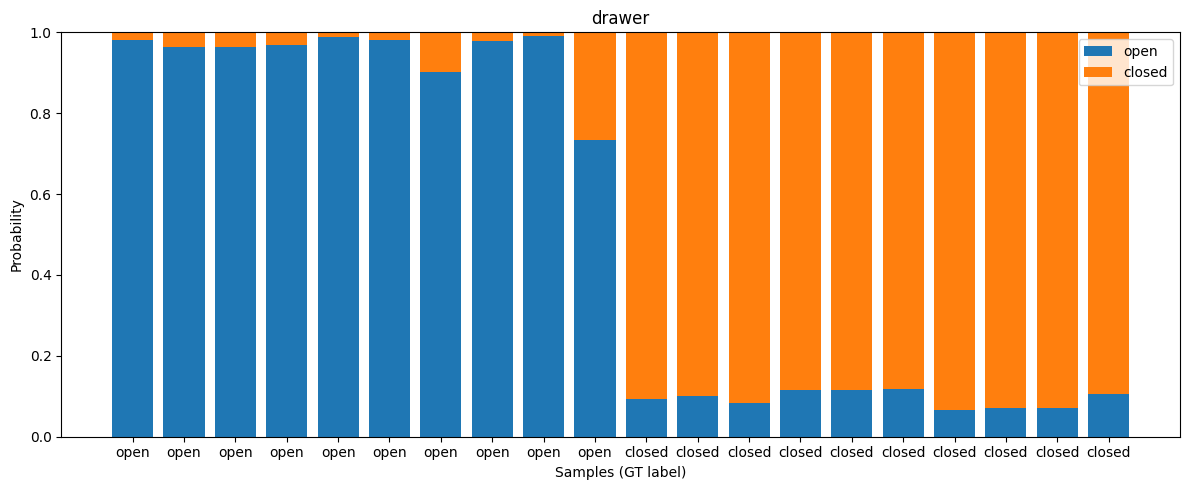

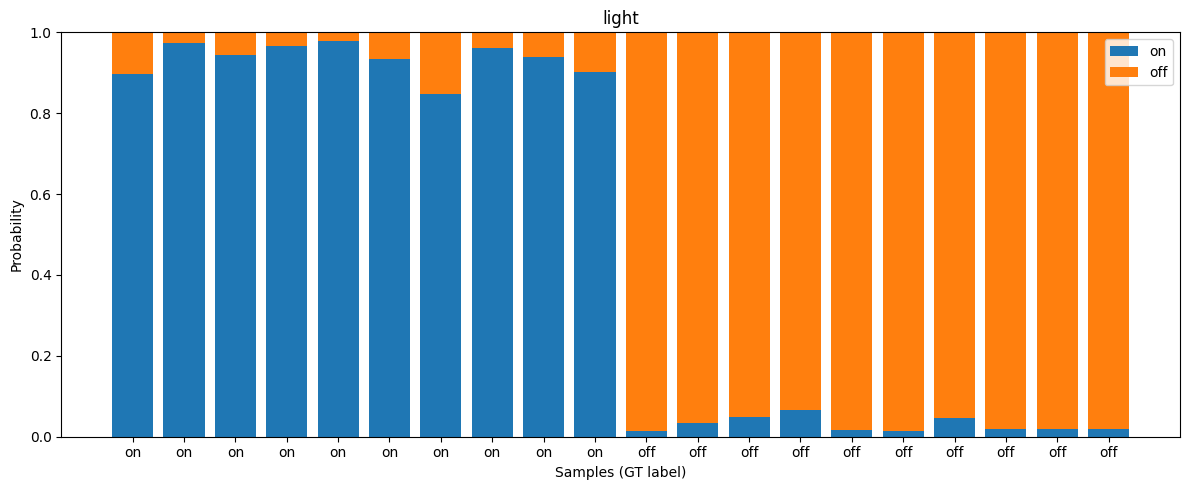

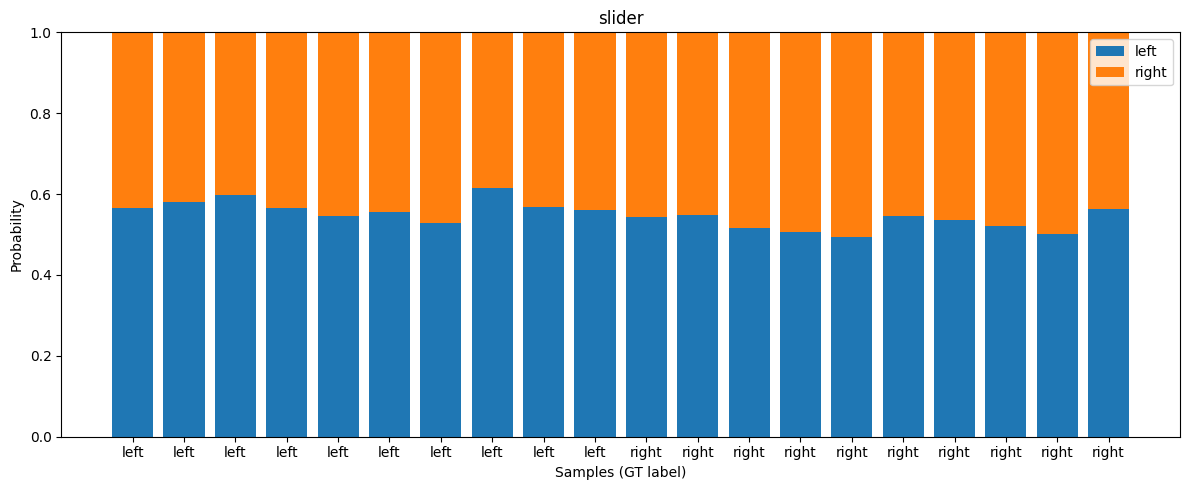

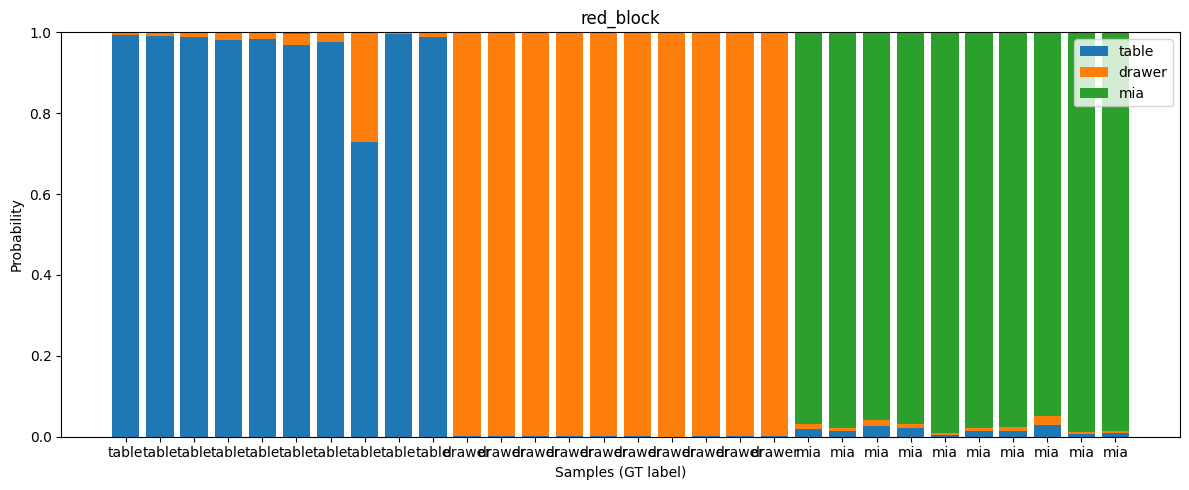

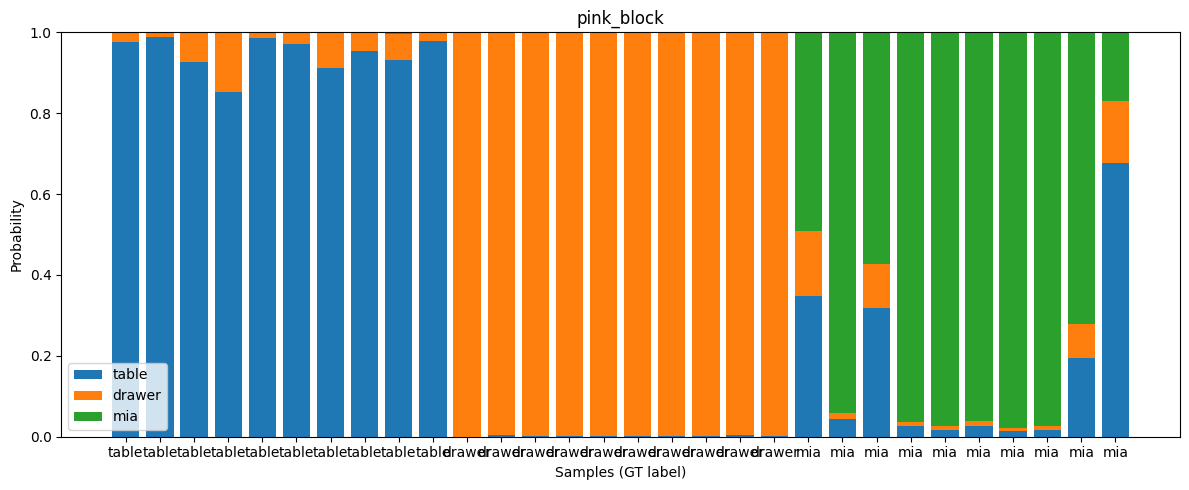

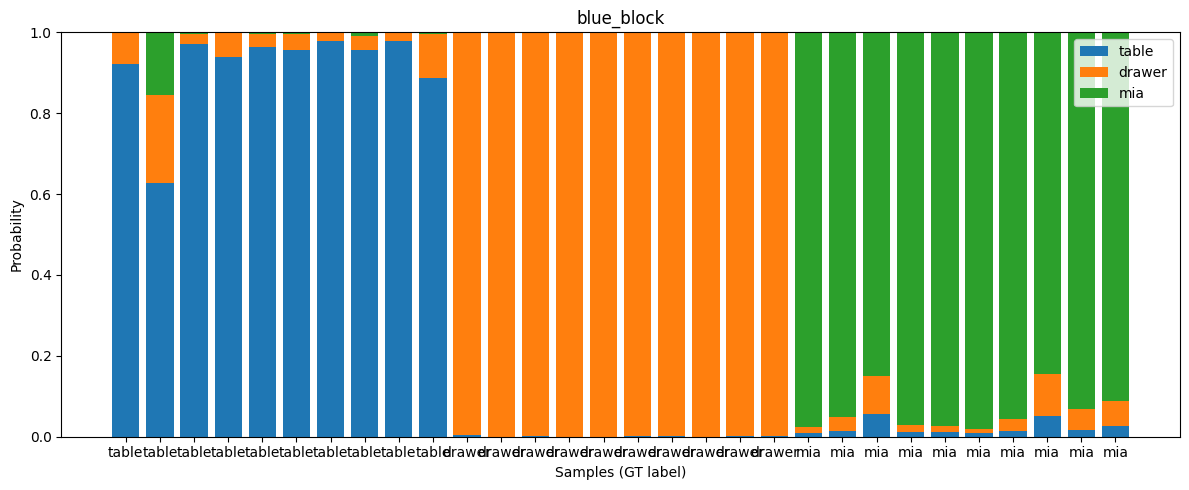

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

grouped = defaultdict(list)

for entity, gt, probs in zip(task_names, ground_truths, probs_predicted):
    grouped[entity].append((gt, probs))

for entity, samples in grouped.items():
    labels = letters_per_task[entity]["states"]
    x = np.arange(len(samples))
    bottoms = np.zeros(len(samples))
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx,label in enumerate(labels):
        values = [probs[idx] for _, probs in samples]
        ax.bar(
            x,
            values,
            bottom=bottoms,
            label=label,
        )

        bottoms += np.array(values)

    # x-axis labels = ground truth labels
    gt_labels = [gt for gt, _ in samples]

    ax.set_xticks(x)
    ax.set_xticklabels(gt_labels)

    ax.set_ylim(0, 1)

    ax.set_title(entity)
    ax.set_ylabel("Probability")
    ax.set_xlabel("Samples (GT label)")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_predictions(
    predicted_states: list[str], ground_truth: list[str], task_names: list[str]
):
    # Evaluate
    correct = 0
    correct_per_task = {entity: 0 for entity in letters_per_task}
    wrong_per_task = {entity: 0 for entity in letters_per_task}
    for i, predicted_state in enumerate(predicted_states):
        entity = task_names[i]
        is_ok = predicted_state == ground_truth[i]
        correct += int(is_ok)
        correct_per_task[entity] += int(is_ok)
        wrong_per_task[entity] += int(not is_ok)

        print(
            f"TASK={entity:<10} "
            f"GT={ground_truth[i]:<10} "
            f"PRED={predicted_state:<10} "
        )

    acc = correct / max(len(predicted_states), 1)
    print(f"\nAccuracy: {acc:.3f} ({correct}/{len(predicted_states)})")
    for entity in letters_per_task:
        task_acc = correct_per_task[entity] / max(
            correct_per_task[entity] + wrong_per_task[entity], 1
        )
        print(
            f"TASK={entity:<10} Accuracy: {task_acc:.3f} ({correct_per_task[entity]}/{correct_per_task[entity] + wrong_per_task[entity]})"
        )


plot_predictions(predicted_letters, ground_truths, task_names)

TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=open       PRED=open       
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=drawer     GT=closed     PRED=closed     
TASK=light      GT=on         PRED=on         
TASK=light   

mia = missing in action = not visible in the picture

Current findings:

Slider:

- Slider accuracy is really hard to improve.
- It fails when the slider is on the right (so it's not the robot arm blocking the view)
- Probabilities show that the model is really uncertain in either case.
- The model also had problems differentiating between the slider and the lever when asked to describe the environment.

Blocks:

- When the red block is there but no pink block, then the model can falsely predict the pink block. And vice versa. (I added the information to the prompt that there are red, blue, and pink blocks in this scene -> strong improvement)
- Still not perfect

Light:

- Works now after I made the prompt more descriptive

Button:

- Ignored for now (but no state extraction for the button is needed)

Drawer:

- Easiest and worked with less description already

General:

- Prompts have to be very descriptive.
- Ogbench has the option to get images without the robot arm -> easier and no occlusion
- Ogbench slider has easier visuals
- Deciding for the location of blocks is so much easier (compared to dinov3)

Options:

- Try a model with more parameters (currently 4B)
- Improve slider prompts somehow
- Make negatives in the prompt more prominent.
- Use another color description for pink?

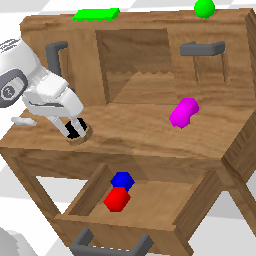

In [ ]:
display(images[0])